In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [93]:
np.random.seed(42)

In [94]:
weeks_data = pd.date_range("2022-01-01","2023-12-31",freq="D")

n = len(weeks_data)

# searches_series = np.random.normal(500,25,len(weeks_data))

# trend
trend = np.linspace(500, 700, n)


# yearly seasonality
yearly_seasonality = 100 * np.sin(2 * np.pi * np.arange(n) / 365)

# weekly seasonality
weekly_seasonality = 50 * np.sin(2 * np.pi * np.arange(n) / 7)

# noise
noise = np.random.normal(0,30,n)

searches_series = trend + yearly_seasonality + weekly_seasonality + noise


fake_ts_df = pd.DataFrame({'date':weeks_data,'searches':searches_series})

fake_ts_df

,date,searches
0,2022-01-01,514.901425
1,2022-01-02,536.939329
2,2022-01-03,572.167910
3,2022-01-04,573.370095
4,2022-01-05,479.258848
...,...,...
725,2023-12-27,663.092439
726,2023-12-28,644.103334
727,2023-12-29,665.625213
728,2023-12-30,680.090700


In [95]:
np.random.seed(42)

fake_ts_df = fake_ts_df.copy()

# Pick 5 random observations
obs_anomaly = np.random.choice(len(fake_ts_df), 5, replace=False)

# Spike them directly — add a large fixed value so they're clearly detectable
fake_ts_df.loc[obs_anomaly, 'searches'] = fake_ts_df.loc[obs_anomaly, 'searches'] + 500

In [96]:

# fake_ts_df.loc[obs_anomaly]
print(fake_ts_df.loc[obs_anomaly, ['date', 'searches']])


          date     searches
468 2023-04-14  1171.349822
148 2022-05-29  1151.312314
302 2022-10-30  1055.956855
355 2022-12-22  1001.442099
515 2023-05-31  1195.329992


In [97]:
fake_ts_df['rolling_mean'] = fake_ts_df['searches'].rolling(30).mean()

fake_ts_df['rolling_std'] = fake_ts_df['searches'].rolling(30).std()

fake_ts_df['z_score'] = (fake_ts_df['searches'] - fake_ts_df['rolling_mean']) / fake_ts_df['rolling_std']
print(fake_ts_df['z_score'])

fake_ts_df['anomaly_flag'] = np.where(fake_ts_df['z_score'].abs()>2.5,1,0)

fake_ts_df.loc[fake_ts_df['anomaly_flag']==1,]

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
725    0.086760
726   -0.262717
727    0.098287
728    0.350412
729    0.973560
Name: z_score, Length: 730, dtype: float64


,date,searches,rolling_mean,rolling_std,z_score,anomaly_flag
65,2022-03-07,697.229331,588.111741,42.780981,2.550610,1
106,2022-04-17,721.551862,621.774392,39.384430,2.533424,1
148,2022-05-29,1151.312314,626.072262,110.460266,4.755013,1
302,2022-10-30,1055.956855,502.113045,114.149549,4.851914,1
351,2022-12-18,655.781280,544.221650,42.671043,2.614411,1
355,2022-12-22,1001.442099,565.068834,93.308015,4.676696,1
468,2023-04-14,1171.349822,730.512715,90.475063,4.872471,1
515,2023-05-31,1195.329992,723.522368,97.352285,4.846395,1


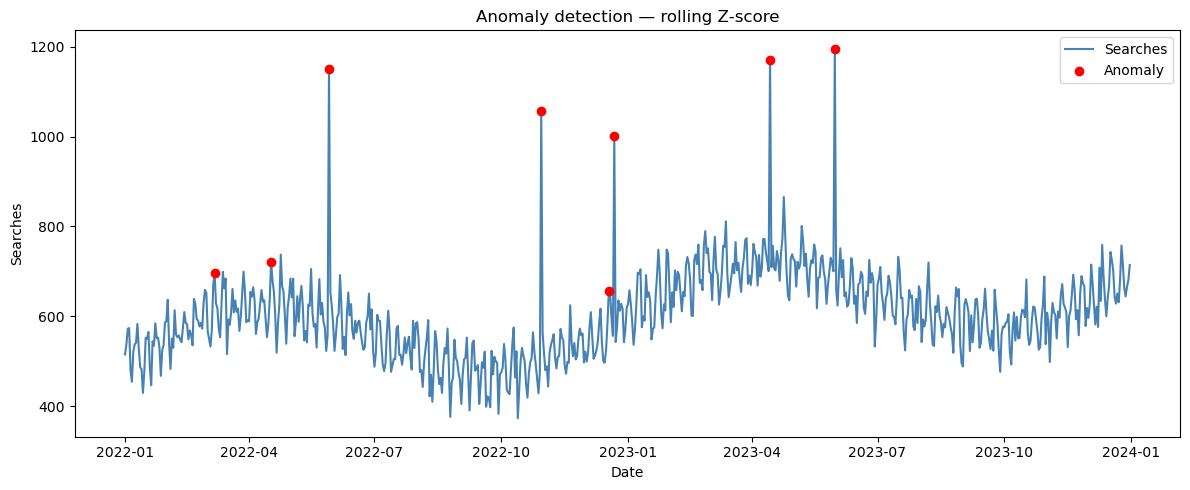

In [98]:
plt.figure(figsize=(12, 5))
plt.plot(fake_ts_df['date'], fake_ts_df['searches'], label='Searches', color='steelblue')
plt.scatter(
    fake_ts_df[fake_ts_df['anomaly_flag'] == 1]['date'],
    fake_ts_df[fake_ts_df['anomaly_flag'] == 1]['searches'],
    color='red', label='Anomaly', zorder=5
)
plt.legend()
plt.title('Anomaly detection — rolling Z-score')
plt.xlabel('Date')
plt.ylabel('Searches')
plt.tight_layout()
plt.show()

In [99]:
Q1 = fake_ts_df['searches'].quantile(0.25)
Q3 = fake_ts_df['searches'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fake_ts_df['anomaly_iqr'] = (
    (fake_ts_df['searches'] < lower_bound) | 
    (fake_ts_df['searches'] > upper_bound)
).astype(int)

print(f"Z-score anomalies detected: {fake_ts_df['anomaly_flag'].sum()}")
print(f"IQR anomalies detected: {fake_ts_df['anomaly_iqr'].sum()}")

Z-score anomalies detected: 8
IQR anomalies detected: 6
